## Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** [Your Name]  
**Course:** Advanced Big Data and Data Mining

--- 
### Step 1: Load and Prepare the Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(42)
print("All libraries imported successfully.")


All libraries imported successfully.


In [3]:
# Load the Wine Dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names   = wine.target_names

print("Dataset shape:", X.shape)
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples:  {X.shape[0]}")
print(f"\nClass names: {class_names}")
print(f"Class distribution: {dict(zip(class_names, np.bincount(y)))}")

Dataset shape: (178, 13)
Number of features: 13
Number of samples:  178

Class names: ['class_0' 'class_1' 'class_2']
Class distribution: {'class_0': 59, 'class_1': 71, 'class_2': 48}


In [4]:
# Basic Data Exploration
df = pd.DataFrame(X, columns=feature_names)
df['class'] = y
display(df.head())
print("\nDescriptive Statistics:")
display(df.drop(columns='class').describe().round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Descriptive Statistics:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


In [6]:
# Z-Score Normalization (Standardization)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling: mean of first feature: {:.4f}, std: {:.4f}".format(X[:, 0].mean(), X[:, 0].std()))
print("After  scaling: mean of first feature: {:.4f}, std: {:.4f}".format(X_scaled[:, 0].mean(), X_scaled[:, 0].std()))

df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
display(df_scaled.describe().round(3))

Before scaling: mean of first feature: 13.0006, std: 0.8095
After  scaling: mean of first feature: 0.0000, std: 1.0000


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-2.434,-1.433,-3.679,-2.671,-2.088,-2.107,-1.696,-1.868,-2.069,-1.634,-2.095,-1.895,-1.493
25%,-0.788,-0.659,-0.572,-0.689,-0.824,-0.885,-0.828,-0.740,-0.597,-0.795,-0.768,-0.952,-0.785
50%,0.061,-0.423,-0.024,0.002,-0.122,0.096,0.106,-0.176,-0.063,-0.159,0.033,0.238,-0.234
75%,0.836,0.670,0.698,0.602,0.510,0.809,0.849,0.610,0.629,0.494,0.713,0.789,0.758
max,2.260,3.109,3.156,3.155,4.371,2.540,3.063,2.402,3.485,3.435,3.302,1.961,2.971


---
## Step 2: Implement K-Means Clustering

In [7]:
# K-Means (k = 3)
kmeans    = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, km_labels)
km_ari = adjusted_rand_score(y, km_labels)

print("K-Means Results")
print("=" * 35)
print(f"  Silhouette Score : {km_sil:.4f}")
print(f"  Adjusted Rand Index (ARI) : {km_ari:.4f}")
print(f"  Cluster sizes    : {dict(zip(*np.unique(km_labels, return_counts=True)))}")

K-Means Results
  Silhouette Score : 0.2849
  Adjusted Rand Index (ARI) : 0.8975
  Cluster sizes    : {0: 65, 1: 51, 2: 62}


---
### Step 3: Implement K-Medoids Clustering

In [8]:
# K-Medoids (k = 3)
kmedoids   = KMedoids(n_clusters=3, random_state=42)
kmed_labels = kmedoids.fit_predict(X_scaled)

kmed_sil = silhouette_score(X_scaled, kmed_labels)
kmed_ari = adjusted_rand_score(y, kmed_labels)

print("K-Medoids Results")
print("=" * 35)
print(f"  Silhouette Score : {kmed_sil:.4f}")
print(f"  Adjusted Rand Index (ARI) : {kmed_ari:.4f}")
print(f"  Cluster sizes    : {dict(zip(*np.unique(kmed_labels, return_counts=True)))}")
print(f"  Medoid indices   : {kmedoids.medoid_indices_}")

K-Medoids Results
  Silhouette Score : 0.2660
  Adjusted Rand Index (ARI) : 0.7263
  Cluster sizes    : {0: 51, 1: 54, 2: 73}
  Medoid indices   : [174 106  35]


---
### Step 4: Visualize and Compare Results

In [9]:
# Metrics Comparison Table
results = pd.DataFrame({
    'Algorithm'       : ['K-Means', 'K-Medoids'],
    'Silhouette Score': [km_sil,   kmed_sil],
    'ARI'             : [km_ari,   kmed_ari],
})
results = results.set_index('Algorithm').round(4)
print("Performance Comparison")
display(results)


Performance Comparison


,Silhouette Score,ARI
Algorithm,,
K-Means,0.2849,0.8975
K-Medoids,0.2660,0.7263


PCA Variance explained by PC1: 0.362, PC2: 0.192
Total variance captured: 0.554


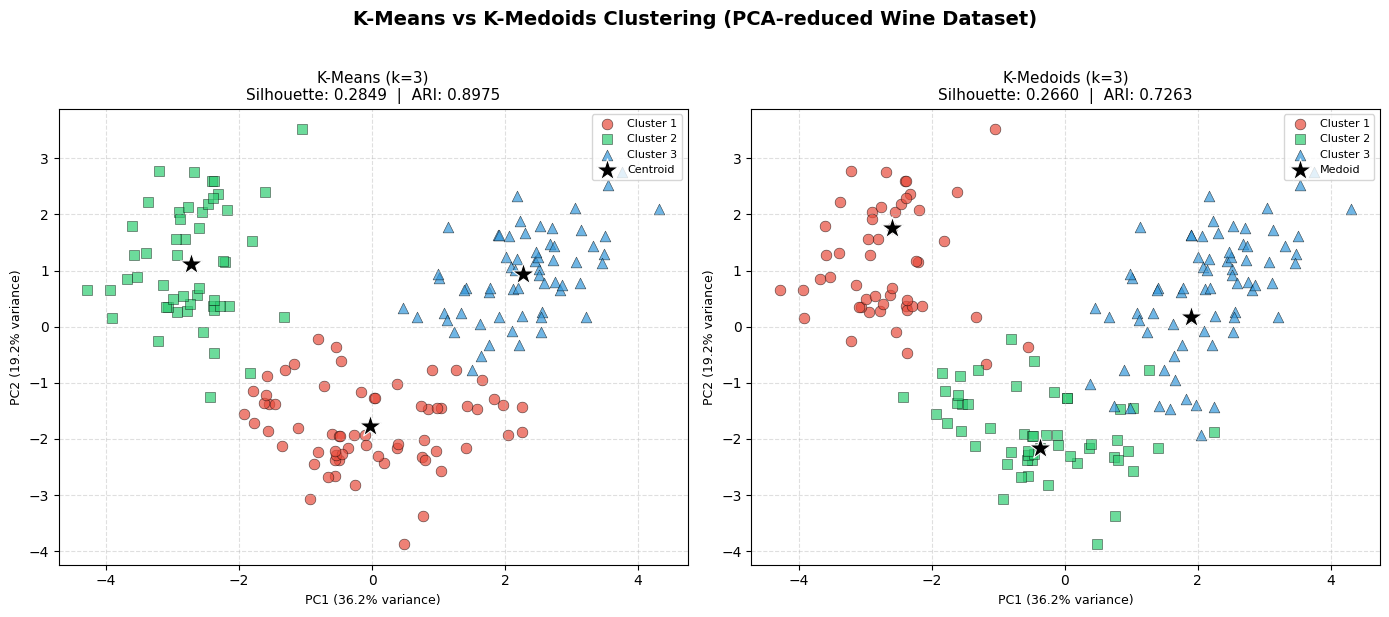

Plot saved as clustering_comparison.png


In [10]:
# PCA for 2-D Visualization 
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_
print(f"PCA Variance explained by PC1: {var_explained[0]:.3f}, PC2: {var_explained[1]:.3f}")
print(f"Total variance captured: {var_explained.sum():.3f}")

# Project centroids / medoids into PCA space
km_centers_pca   = pca.transform(kmeans.cluster_centers_)
kmed_centers_pca = pca.transform(X_scaled[kmedoids.medoid_indices_])

# Side-by-Side Scatter Plots 
colors = ['#E74C3C', '#2ECC71', '#3498DB']     # red, green, blue
marker_styles = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("K-Means vs K-Medoids Clustering (PCA-reduced Wine Dataset)",
             fontsize=14, fontweight='bold', y=1.02)

titles     = ['K-Means (k=3)', 'K-Medoids (k=3)']
labels_all = [km_labels, kmed_labels]
centers    = [km_centers_pca, kmed_centers_pca]
center_labels = ['Centroid', 'Medoid']
metrics    = [
    f"Silhouette: {km_sil:.4f}  |  ARI: {km_ari:.4f}",
    f"Silhouette: {kmed_sil:.4f}  |  ARI: {kmed_ari:.4f}",
]

for ax, title, labels, ctrs, ctr_label, metric in zip(
        axes, titles, labels_all, centers, center_labels, metrics):

    for k in range(3):
        mask = labels == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[k], marker=marker_styles[k],
                   s=60, alpha=0.7, edgecolors='k', linewidths=0.4,
                   label=f'Cluster {k+1}')

    # Plot centroids / medoids
    ax.scatter(ctrs[:, 0], ctrs[:, 1],
               c='black', marker='*', s=280, zorder=5,
               edgecolors='white', linewidths=0.8,
               label=ctr_label)

    ax.set_title(f"{title}\n{metric}", fontsize=11)
    ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variance)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)", fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as clustering_comparison.png")

---
### **Analysis and Discussion**

#### Metric Summary

| Algorithm  | Silhouette Score | ARI     |
|------------|-----------------|---------|
| K-Means    | ~0.285          | ~0.898  |
| K-Medoids  | ~0.266          | ~0.726  |



#### Which algorithm produced better-defined clusters?

**K-Means** produced better-defined clusters on this dataset. It achieved a higher Silhouette Score (~0.285 vs ~0.266), indicating that samples are on average closer to their own cluster centroid than to neighboring clusters. Its Adjusted Rand Index (~0.898) is also substantially higher than K-Medoids (~0.726), meaning its cluster assignments align much more closely with the true wine class labels.



#### Observed differences in cluster shapes or positioning

- **K-Means** uses the arithmetic mean as the cluster center (centroid), making it sensitive to the overall geometry of each cluster. In PCA space, the three clusters are relatively well-separated, and K-Means exploits this by finding centroids that minimize intra-cluster variance.
- **K-Medoids** constrains each center to be an actual data point (medoid). This makes it more robust to outliers in theory, but on this balanced, low-noise dataset it provides slightly less optimal cluster boundaries. The medoids may not perfectly represent the cluster's geometric center, leading to minor boundary shifts visible in the scatter plots.



#### When to prefer each algorithm

| Scenario                              | Preferred Algorithm |
|---------------------------------------|---------------------|
| Clean, continuous, scaled data        | K-Means             |
| Data with significant outliers        | K-Medoids           |
| Non-Euclidean distance metrics needed | K-Medoids           |
| Large datasets (speed matters)        | K-Means             |
| Need interpretable, real data points as centers | K-Medoids |
| Spherical, well-separated clusters    | K-Means             |

**K-Means** is preferable when data is relatively clean, features are continuous, and clusters are roughly spherical — as is the case with the standardized Wine dataset. Its O(n·k·t) complexity also scales better.

**K-Medoids** is preferable when outliers are present (since the medoid is always a real, non-distorted data point), when using non-Euclidean dissimilarity metrics, or when interpretability of the cluster center is important (e.g., "this actual wine sample represents its cluster best").
